# State-Space Models — From Linear ODEs to Mamba
### `03_State_Space_Models/SSM_S4_Mamba_HiPPO/`

> **Learning goal:** Derive the continuous-time linear state-space model, discretize it (ZOH / bilinear), understand **HiPPO** as optimal continuous-time memory, implement a minimal **S4-style** convolutional kernel, and see how **Mamba** makes the dynamics *input-selective*. This is Phase 4 of the Causal-Dynamical AI roadmap — the scalable memory engine that sits between classical dynamical systems (Phase 0) and world models (Phase 7).

> **You already have the prerequisites** from earlier notebooks:
> - 1D flows & stability → eigenvalues of $A$ control memory lifetime  
> - Linear systems (Strogatz Ch.5) → phase portraits of $\dot{x}=Ax$  
> - Discrete maps → $x_{n+1}=f(x_n)$ as the discrete engine of generation  

> **Primary references:** Gu et al. S4 (ICLR 2022); Gu & Dao Mamba (2023); Gu et al. HiPPO (NeurIPS 2020); Kalman (1960).

---

## Why SSMs for AI?

| Architecture | State | Sequence cost | Strength |
|---|---|---|---|
| Transformer | None (full KV cache) | $\mathcal{O}(L^2)$ attention | Soft routing, in-context learning |
| RNN / LSTM | Fixed $h_t$ | $\mathcal{O}(L)$ | Causal streaming; hard to train long |
| **S4 / Mamba SSM** | Linear latent $h_t$ | $\mathcal{O}(L)$ (scan / conv) | Long memory + parallel training |

An SSM is literally the same object as a linear world model:

$$
\begin{aligned}
\dot{h}(t) &= A\, h(t) + B\, x(t) \\
y(t) &= C\, h(t) + D\, x(t)
\end{aligned}
$$

Here $x(t)$ is the input token stream, $h(t)$ is compressed memory, $y(t)$ is the feature used by the next layer. **World models** use the same equations with $x$ = action/obs and $y$ = predicted next latent.

## 1. Continuous-Time Linear SSM

### 1A. The equations

State $h(t) \in \mathbb{R}^N$, input $x(t) \in \mathbb{R}$, output $y(t) \in \mathbb{R}$:

$$
\boxed{
\dot{h}(t) = A h(t) + B x(t),
\qquad
y(t) = C h(t) + D x(t)
}
$$

**Solution (variation of constants):**

$$
h(t) = e^{A t} h(0) + \int_0^t e^{A(t-\tau)} B x(\tau)\, d\tau
$$

The matrix exponential $e^{At}$ is the **continuous-time state transition**. Its eigenvalues determine whether memory **contracts** (stable, $\mathrm{Re}(\lambda)<0$), **persists**, or **explodes**.

### 1B. Stability (link to Phase 0)

From `Linear_Systems.ipynb` and `Flows_on_the_Line.ipynb`:

- If all eigenvalues of $A$ satisfy $\mathrm{Re}(\lambda_i) < 0$, then $e^{At} \to 0$ and the system forgets initial conditions — **stable memory** that integrates inputs.
- If some $\mathrm{Re}(\lambda_i) > 0$, trajectories explode — useless as a latent state for long sequences unless carefully constrained.
- S4 parameterizes $A$ so this is guaranteed (e.g. diagonal plus low-rank with negative real parts / HiPPO structure).

### 1C. Impulse response = convolutional kernel

Set $h(0)=0$, $x(t)=\delta(t)$. Then

$$
K(t) = C e^{At} B, \qquad y = K * x.
$$

**Training insight (S4):** instead of scanning RNN-style, materialize $K$ and do a convolution (FFT) — fully parallel over sequence length.

Eigenvalues of A: [-0.4+0.8j -0.4-0.8j]


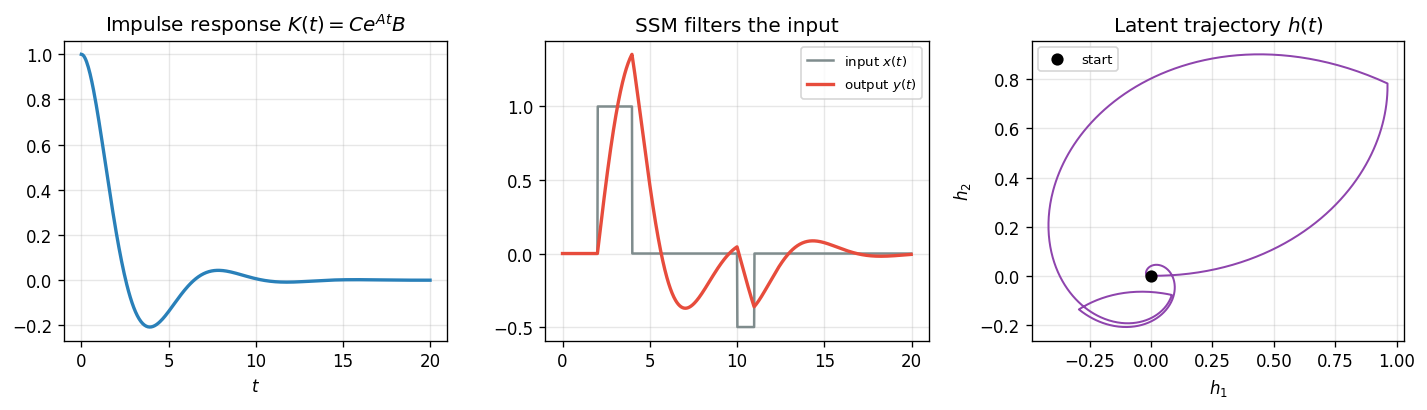

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigvals, matrix_power, inv, solve

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

def expm_scale_square(A, t, n_terms=20):
    """Simple scaling-and-squaring free Taylor expm for small demo matrices."""
    # For pedagogy; use scipy.linalg.expm in production
    from math import factorial
    At = A * t
    # scale
    s = int(np.ceil(np.log2(max(1.0, np.linalg.norm(At, ord=np.inf)))))
    B = At / (2 ** s)
    E = np.eye(A.shape[0])
    P = np.eye(A.shape[0])
    for k in range(1, n_terms + 1):
        P = P @ B / k
        E = E + P
    for _ in range(s):
        E = E @ E
    return E

# Stable 2D latent: spiral sink
theta = 0.8
A = np.array([[-0.4, -theta],
              [theta, -0.4]])
B = np.array([[1.0], [0.0]])
C = np.array([[1.0, 0.5]])
D = np.array([[0.0]])

print("Eigenvalues of A:", eigvals(A))

# Impulse response K(t)
ts = np.linspace(0, 20, 400)
K = np.array([(C @ expm_scale_square(A, t) @ B).item() for t in ts])

# Drive with a square pulse and integrate SSM with Euler
dt = 0.02
T = 20.0
t = np.arange(0, T, dt)
x = ((t > 2) & (t < 4)).astype(float) - 0.5 * ((t > 10) & (t < 11)).astype(float)
h = np.zeros(2)
ys = []
hs = []
for xt in x:
    h = h + dt * (A @ h + B.ravel() * xt)
    y = (C @ h).item() + D.item() * xt
    ys.append(y)
    hs.append(h.copy())
hs = np.array(hs)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].plot(ts, K, color="#2980B9", lw=2)
axes[0].set_title(r"Impulse response $K(t)=C e^{At} B$")
axes[0].set_xlabel("$t$"); axes[0].grid(True, alpha=0.3)

axes[1].plot(t, x, label="input $x(t)$", color="#7F8C8D")
axes[1].plot(t, ys, label="output $y(t)$", color="#E74C3C", lw=2)
axes[1].set_title("SSM filters the input")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

axes[2].plot(hs[:, 0], hs[:, 1], color="#8E44AD", lw=1.2)
axes[2].scatter(hs[0, 0], hs[0, 1], c="k", s=40, zorder=5, label="start")
axes[2].set_title("Latent trajectory $h(t)$")
axes[2].set_xlabel("$h_1$"); axes[2].set_ylabel("$h_2$")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3); axes[2].set_aspect("equal")
plt.tight_layout()
plt.savefig("SSM_A_continuous_impulse.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Discretization — From ODE to Sequence Model

Neural sequence models see tokens at steps $k = 0,1,2,\ldots$ with step size $\Delta$. We need

$$
h_{k+1} = \bar{A}\, h_k + \bar{B}\, x_k,
\qquad
y_k = \bar{C}\, h_k + \bar{D}\, x_k.
$$

### 2A. Zero-Order Hold (ZOH)

Assume $x(t)$ constant on $[k\Delta, (k+1)\Delta)$:

$$
\bar{A} = e^{A\Delta},
\qquad
\bar{B} = \left(\int_0^{\Delta} e^{A\tau}\, d\tau\right) B
= A^{-1}(e^{A\Delta} - I) B
\quad (A \text{ invertible}).
$$

### 2B. Bilinear (Tustin) transform

$$
\bar{A} = \left(I - \tfrac{\Delta}{2} A\right)^{-1}\left(I + \tfrac{\Delta}{2} A\right),
\qquad
\bar{B} = \left(I - \tfrac{\Delta}{2} A\right)^{-1} \Delta\, B,
\qquad
\bar{C} = C.
$$

Used heavily in S4 for numerical convenience.

### 2C. Unrolling = convolution

$$
y_k = \sum_{j=0}^{k} C \bar{A}^{k-j} \bar{B}\, x_j + D x_k
= (K * x)_k,
\qquad
K_j = C \bar{A}^{j} \bar{B}\ (j\ge 1),\ K_0 = CB+D.
$$

This is the **S4 training view**: compute $K_{0:L}$ once, FFT-convolve with $x$.

max |scan - conv| = 4.440892098500626e-16
Spectral radius of Ab: 0.9607894391523231


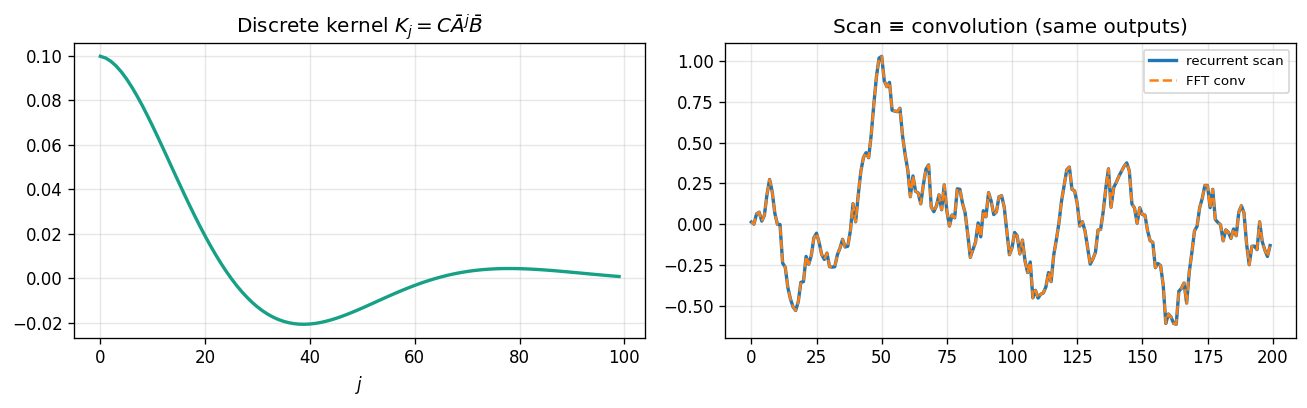

In [2]:
def discretize_zoh(A, B, C, D, delta):
    Ab = expm_scale_square(A, delta)
    # ∫_0^Δ e^{Aτ} dτ B  ≈  A^{-1}(e^{AΔ}-I) B
    try:
        Bb = inv(A) @ (Ab - np.eye(A.shape[0])) @ B
    except np.linalg.LinAlgError:
        # fallback rectangle rule
        Bb = delta * B
    return Ab, Bb, C.copy(), D.copy()

def discretize_bilinear(A, B, C, D, delta):
    I = np.eye(A.shape[0])
    left = inv(I - 0.5 * delta * A)
    Ab = left @ (I + 0.5 * delta * A)
    Bb = left @ (delta * B)
    return Ab, Bb, C.copy(), D.copy()

def ssm_kernel(Ab, Bb, C, D, L):
    """K[0..L-1] for causal conv."""
    K = np.zeros(L)
    # K_0 = C B + D  (discrete; after disc Bb already absorbs Δ)
    v = Bb.ravel()
    K[0] = (C @ v).item() + D.item()
    for j in range(1, L):
        v = Ab @ v
        K[j] = (C @ v).item()
    return K

def ssm_scan(Ab, Bb, C, D, x):
    h = np.zeros(Ab.shape[0])
    ys = np.zeros_like(x)
    for k, xk in enumerate(x):
        h = Ab @ h + Bb.ravel() * xk
        ys[k] = (C @ h).item() + D.item() * xk
    return ys

def fft_conv_causal(K, x):
    L = len(x)
    n = 1 << int(np.ceil(np.log2(2 * L)))
    y = np.fft.irfft(np.fft.rfft(K, n) * np.fft.rfft(x, n), n)
    return y[:L]

delta = 0.1
Ab, Bb, Cb, Db = discretize_zoh(A, B, C, D, delta)
Kb = ssm_kernel(Ab, Bb, Cb, Db, L=200)

# random input
rng = np.random.default_rng(0)
x = rng.normal(size=200)
y_scan = ssm_scan(Ab, Bb, Cb, Db, x)
y_conv = fft_conv_causal(Kb, x)

print("max |scan - conv| =", np.max(np.abs(y_scan - y_conv)))
print("Spectral radius of Ab:", np.max(np.abs(eigvals(Ab))))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(Kb[:100], color="#16A085", lw=2)
axes[0].set_title(r"Discrete kernel $K_j = C \bar{A}^j \bar{B}$")
axes[0].set_xlabel("$j$"); axes[0].grid(True, alpha=0.3)

axes[1].plot(y_scan, label="recurrent scan", lw=2)
axes[1].plot(y_conv, "--", label="FFT conv", lw=1.5)
axes[1].set_title("Scan ≡ convolution (same outputs)")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("SSM_B_discretize_conv.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. HiPPO — Optimal Continuous-Time Memory

### 3A. The problem

Compress a function $f(t)$ observed on $[0,t]$ into a finite state $h(t) \in \mathbb{R}^N$ so that $f$ can be reconstructed on the past. Naïve uniform sampling wastes capacity on the recent past and forgets the long past (or vice versa).

### 3B. HiPPO operator (LegT)

**HiPPO** (High-order Polynomial Projection Operators) projects $f$ onto an orthogonal polynomial basis (e.g. Legendre) online. For the translated Legendre (LegT) measure, the state satisfies

$$
\dot{h}(t) = A_{\mathrm{HiPPO}}\, h(t) + B_{\mathrm{HiPPO}}\, f(t)
$$

with a **structured** $A$ (low-rank + diagonal / companion-like), approximately:

$$
(A_{\mathrm{HiPPO}})_{nk}
=
-
\begin{cases}
(2n+1)^{1/2}(2k+1)^{1/2} & n > k \\
n+1 & n = k \\
0 & n < k
\end{cases}
\quad
\text{(LegT form; up to scaling conventions).}
$$

The point: **$A$ is not learned from scratch as a dense matrix** — it is initialized to the operator that optimally memorizes continuous history in a polynomial basis. S4 builds on this.

### 3C. Intuition

| Basis coefficient | Role |
|---|---|
| Low order ($n$ small) | Coarse / long-timescale summary of the past |
| High order ($n$ large) | Fine detail of the recent past |

This is hierarchical memory for free — the same multi-timescale idea as two-timing in limit cycles, now as linear algebra.

HiPPO-LegT eigenvalue real parts (min/max): -16.0 -1.0


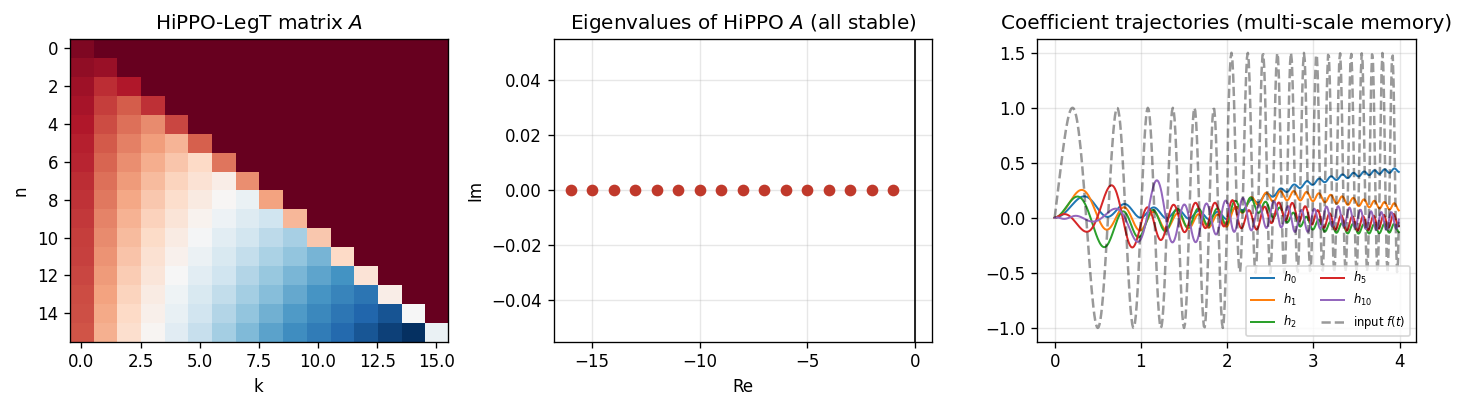

In [3]:
def hippo_legt_matrix(N):
    """HiPPO-LegT A, B as in Gu et al. (simplified standard form)."""
    A = np.zeros((N, N))
    for n in range(N):
        for k in range(N):
            if n > k:
                A[n, k] = -np.sqrt((2 * n + 1) * (2 * k + 1))
            elif n == k:
                A[n, k] = -(n + 1)
            else:
                A[n, k] = 0.0
    B = np.sqrt(2 * np.arange(N) + 1.0)
    return A, B

N = 16
A_h, B_h = hippo_legt_matrix(N)
evals = eigvals(A_h)
print("HiPPO-LegT eigenvalue real parts (min/max):",
      evals.real.min(), evals.real.max())

# Online compress a signal, then reconstruct with Legendre-ish readout demo:
# We integrate h' = A h + B f, then y = sum h_n * basis weight (toy: use C = B^T style)
delta = 0.01
T = 4.0
t = np.arange(0, T, delta)
# signal: chirp + step
f = np.sin(2 * np.pi * (1 + t) * t) + 0.5 * (t > 2)

Ab, Bb, _, _ = discretize_zoh(A_h, B_h.reshape(-1, 1),
                              np.ones((1, N)), np.zeros((1, 1)), delta)
# store trajectory of coefficients
h = np.zeros(N)
H = []
for ft in f:
    h = Ab @ h + Bb.ravel() * ft
    H.append(h.copy())
H = np.array(H)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].imshow(A_h, cmap="RdBu_r", aspect="auto")
axes[0].set_title(r"HiPPO-LegT matrix $A$")
axes[0].set_xlabel("k"); axes[0].set_ylabel("n")

axes[1].plot(evals.real, evals.imag, "o", color="#C0392B")
axes[1].axvline(0, color="k", lw=1)
axes[1].set_title("Eigenvalues of HiPPO $A$ (all stable)")
axes[1].set_xlabel("Re"); axes[1].set_ylabel("Im"); axes[1].grid(True, alpha=0.3)

# show first few coefficient trajectories
for n in [0, 1, 2, 5, 10]:
    axes[2].plot(t, H[:, n], label=f"$h_{{{n}}}$", lw=1.2)
axes[2].plot(t, f, "k--", alpha=0.4, label="input $f(t)$")
axes[2].set_title("Coefficient trajectories (multi-scale memory)")
axes[2].legend(fontsize=7, ncol=2); axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("SSM_C_hippo.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. S4 in One Page

**Structured State Space Sequence model (S4)** combines:

1. **HiPPO-initialized** $A$ (stable, long memory).
2. **DPLR / diagonal** parameterization so $e^{A\Delta}$ and the kernel $K$ are computable in near-linear time.
3. **Convolution view** for parallel training; **recurrent view** for efficient autoregressive inference.
4. Stacked layers + nonlinearities + mixing (like a Transformer block, but SSM replaces attention).

### Minimal S4 block (educational)

$$
x \xrightarrow{\text{Linear}} u
\xrightarrow{\text{SSM kernel } K}
v
\xrightarrow{\sigma}
\xrightarrow{\text{Linear}} y
$$

Multiple independent SSM channels (heads) capture different timescales.

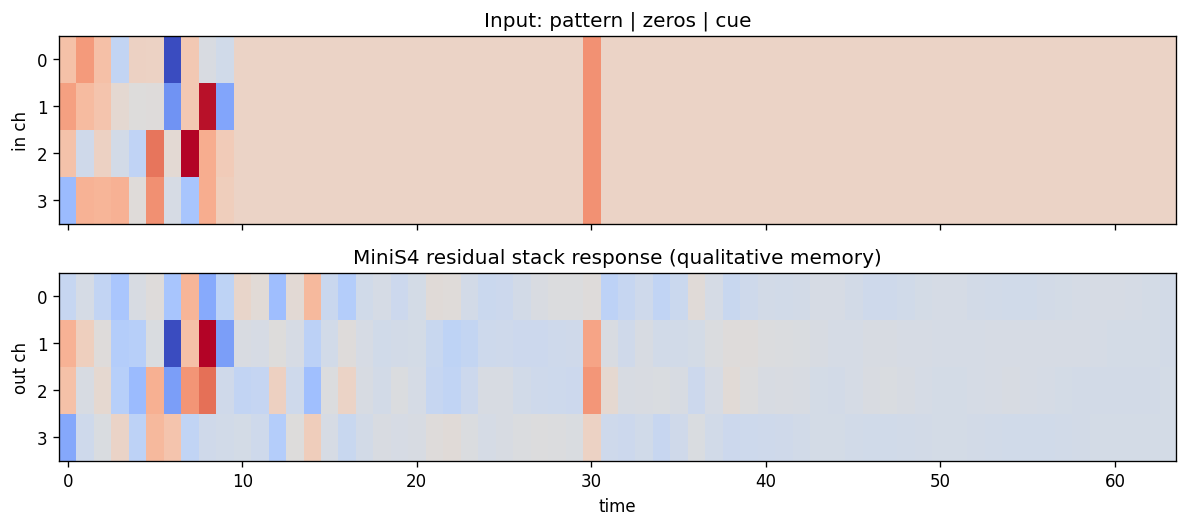

Output energy before cue: 3.3901508512394494
Output energy after cue: 3.2898567822409084


In [4]:
# ── Minimal multi-channel S4-style layer (NumPy) ─────────────────────────────

class MiniS4Layer:
    """Depthwise SSM channels + GELU + pointwise mix. Educational, not paper-exact."""

    def __init__(self, d_model=8, d_state=16, delta=0.05, seed=0):
        rng = np.random.default_rng(seed)
        self.d_model = d_model
        self.channels = []
        for _ in range(d_model):
            A, B = hippo_legt_matrix(d_state)
            # slight randomize C, D; scale A for channel diversity
            scale = float(rng.uniform(0.5, 1.5))
            C = rng.normal(size=(1, d_state)) / np.sqrt(d_state)
            D = rng.normal(size=(1, 1)) * 0.1
            Ab, Bb, Cb, Db = discretize_zoh(scale * A, B.reshape(-1, 1), C, D, delta)
            self.channels.append((Ab, Bb, Cb, Db))
        self.out_mix = rng.normal(size=(d_model, d_model)) / np.sqrt(d_model)

    def kernel(self, L):
        return [ssm_kernel(Ab, Bb, C, D, L) for Ab, Bb, C, D in self.channels]

    def forward(self, x):
        """x: (L, d_model) -> (L, d_model)"""
        L, d = x.shape
        assert d == self.d_model
        ys = []
        for i, (Ab, Bb, C, D) in enumerate(self.channels):
            K = ssm_kernel(Ab, Bb, C, D, L)
            ys.append(fft_conv_causal(K, x[:, i]))
        y = np.stack(ys, axis=1)
        y = np.tanh(y)  # cheap nonlinearity (stand-in for GELU)
        return y @ self.out_mix.T

# Memorization probe: copy a random pattern after a delay
L = 64
delay = 20
rng = np.random.default_rng(1)
pattern = rng.normal(size=(10, 4))
x = np.zeros((L, 4))
x[:10] = pattern
# markers
x[10:10+delay, :] = 0.0
x[10+delay] = 1.0  # go cue on all channels (broadcast)

layer = MiniS4Layer(d_model=4, d_state=24, delta=0.08, seed=2)
# stack 3 layers
h = x.copy()
for _ in range(3):
    h = layer.forward(h) + h  # residual

fig, axes = plt.subplots(2, 1, figsize=(10, 4.5), sharex=True)
axes[0].imshow(x.T, aspect="auto", cmap="coolwarm", interpolation="nearest")
axes[0].set_ylabel("in ch"); axes[0].set_title("Input: pattern | zeros | cue")
axes[1].imshow(h.T, aspect="auto", cmap="coolwarm", interpolation="nearest")
axes[1].set_ylabel("out ch"); axes[1].set_xlabel("time")
axes[1].set_title("MiniS4 residual stack response (qualitative memory)")
plt.tight_layout()
plt.savefig("SSM_D_minis4_memory.png", dpi=150, bbox_inches="tight")
plt.show()
print("Output energy before cue:", np.linalg.norm(h[10:10+delay]))
print("Output energy after cue:", np.linalg.norm(h[10+delay:]))

## 5. Mamba — Selective State Spaces

S4 is **LTI** (linear time-invariant): $A,B,C$ do not depend on the current token. That is great for long convolution, but bad when you need to **ignore** whitespace / noise tokens and **focus** on rare, important tokens.

### 5A. Selectivity

Mamba makes $B$, $C$, and $\Delta$ **input-dependent**:

$$
\begin{aligned}
B_k &= \mathrm{Linear}_B(x_k), \\
C_k &= \mathrm{Linear}_C(x_k), \\
\Delta_k &= \mathrm{softplus}(\mathrm{Linear}_\Delta(x_k)), \\
\bar{A}_k, \bar{B}_k &= \mathrm{discretize}(A, B_k, \Delta_k).
\end{aligned}
$$

Dynamics become **time-varying**:

$$
h_{k+1} = \bar{A}_k h_k + \bar{B}_k x_k.
$$

You can no longer use a single global convolution kernel. Instead, Mamba uses a **parallel associative scan** (still $\mathcal{O}(L)$ hardware-efficient).

### 5B. Selection as gating (intuition)

Large $\Delta_k$ + appropriate $B_k$ → write hard into state (remember this token).  
Small $\Delta_k$ → state barely updates (skip / forget this token).

This is the continuous-time cousin of LSTM gates — but with structured multi-dimensional state instead of a single cell.

### 5C. Selective scan (educational implementation)

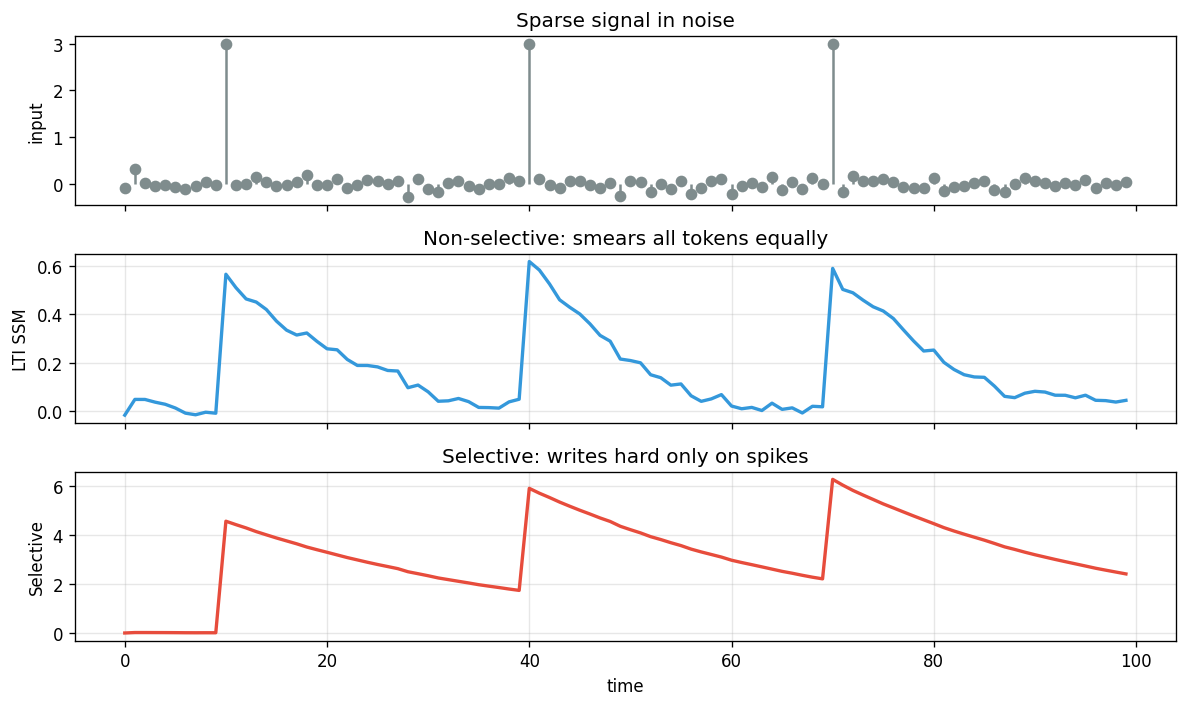

In [5]:
def selective_scan(A_log, B_seq, C_seq, delta_seq, x):
    """
    Educational selective SSM scan (diagonal A).
    A_log: (N,) negative log-space diagonal of continuous A
    B_seq: (L, N)
    C_seq: (L, N)
    delta_seq: (L,) positive
    x: (L,)
    returns y: (L,)
    """
    L, N = B_seq.shape
    # continuous A is -exp(A_log) on diagonal (always stable)
    A = -np.exp(A_log)  # (N,)
    h = np.zeros(N)
    ys = np.zeros(L)
    for k in range(L):
        # ZOH for diagonal: ā = exp(Δ A), b̄ = (ā - 1)/A * B  (elementwise)
        d = delta_seq[k]
        Abar = np.exp(d * A)              # (N,)
        # (exp(Δa)-1)/a * b * x , with a = A[n] < 0
        Bbar = ((Abar - 1.0) / A) * B_seq[k] * x[k]
        h = Abar * h + Bbar
        ys[k] = np.dot(C_seq[k], h)
    return ys

rng = np.random.default_rng(3)
L, N = 100, 8
A_log = rng.normal(size=N) * 0.1
# Synthetic: most tokens noise; sparse spikes carry signal to copy later
x = rng.normal(size=L) * 0.1
spike_times = [10, 40, 70]
for s in spike_times:
    x[s] = 3.0

# Non-selective: constant B,C,delta
B_const = np.ones((L, N)) * 0.5
C_const = np.ones((L, N)) * 0.5
d_const = np.ones(L) * 0.1
y_lti = selective_scan(A_log, B_const, C_const, d_const, x)

# Selective: enlarge B and delta on large |x|
B_sel = np.ones((L, N)) * 0.1
C_sel = np.ones((L, N)) * 0.5
d_sel = np.ones(L) * 0.02
for k in range(L):
    gate = 1 / (1 + np.exp(-3 * (np.abs(x[k]) - 1.0)))  # sigmoid gate
    B_sel[k] = 0.1 + 1.5 * gate
    d_sel[k] = 0.02 + 0.25 * gate
y_sel = selective_scan(A_log, B_sel, C_sel, d_sel, x)

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
axes[0].stem(np.arange(L), x, linefmt="#7F8C8D", markerfmt="o", basefmt=" ")
axes[0].set_ylabel("input"); axes[0].set_title("Sparse signal in noise")
axes[1].plot(y_lti, color="#3498DB", lw=2)
axes[1].set_ylabel("LTI SSM"); axes[1].set_title("Non-selective: smears all tokens equally")
axes[1].grid(True, alpha=0.3)
axes[2].plot(y_sel, color="#E74C3C", lw=2)
axes[2].set_ylabel("Selective"); axes[2].set_title("Selective: writes hard only on spikes")
axes[2].set_xlabel("time"); axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("SSM_E_mamba_selection.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Eigenvalue Placement — Memory Lifetime as Design

For a diagonal discrete mode $\bar{a} = e^{\Delta \lambda}$ with $\lambda < 0$:

$$
\text{memory half-life (steps)}
\approx
\frac{\ln 1/2}{\ln |\bar{a}|}
=
\frac{\ln 2}{\Delta |\lambda|}.
$$

- Fast modes ($|\lambda|$ large): short memory, high bandwidth.  
- Slow modes ($|\lambda|$ near 0): long memory, integrate rare events.

**Mamba's $\Delta_k$** modulates this per token: the same mode can act fast or slow depending on content.

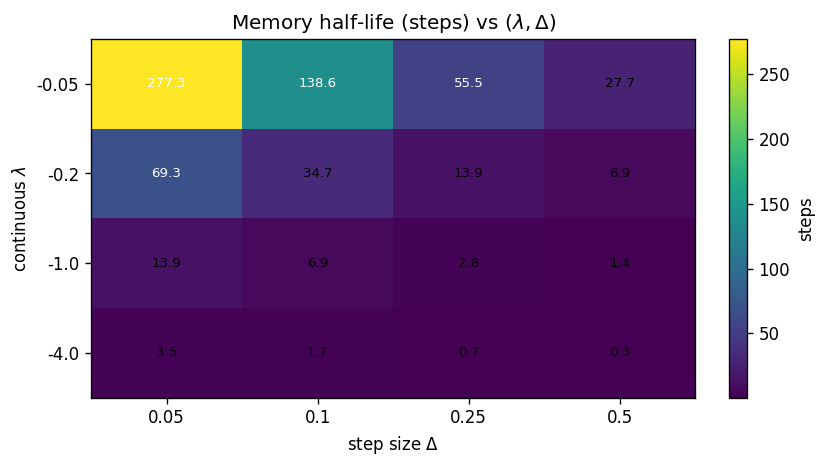

In [6]:
lambdas = np.array([-0.05, -0.2, -1.0, -4.0])
deltas = np.array([0.05, 0.1, 0.25, 0.5])
half_lives = np.zeros((len(lambdas), len(deltas)))
for i, lam in enumerate(lambdas):
    for j, d in enumerate(deltas):
        abar = np.exp(d * lam)
        half_lives[i, j] = np.log(0.5) / np.log(np.abs(abar))

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(half_lives, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(deltas))); ax.set_xticklabels([str(d) for d in deltas])
ax.set_yticks(range(len(lambdas))); ax.set_yticklabels([str(l) for l in lambdas])
ax.set_xlabel(r"step size $\Delta$"); ax.set_ylabel(r"continuous $\lambda$")
ax.set_title("Memory half-life (steps) vs $(\lambda, \Delta)$")
for i in range(len(lambdas)):
    for j in range(len(deltas)):
        ax.text(j, i, f"{half_lives[i, j]:.1f}", ha="center", va="center",
                color="white" if half_lives[i, j] > half_lives.mean() else "black", fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046, label="steps")
plt.tight_layout()
plt.savefig("SSM_F_memory_halflife.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Bridge: SSM as a World-Model Backbone

| World-model need | SSM mechanism |
|---|---|
| Compress history $o_{1:t}$ | State $h_t$ with HiPPO / selective write |
| Roll out imagination $s_{t+1}=f(s_t,a_t)$ | Same linear/selective dynamics with action as input channel |
| Long-horizon credit | Slow eigenmodes + selection |
| Online / streaming agents | Recurrent mode $\mathcal{O}(1)$ per step |
| Parallel training on video | Convolution / scan over time |

**Dreamer-style RSSM** is a stochastic nonlinear cousin: $h_{t+1}=f(h_t,z_t,a_t)$ with $z_t$ discrete latents. Mamba shows you can get very long effective memory with *linear* selective dynamics — a strong inductive bias before adding stochastic latents.

**Connection to Phase 6 (MCTS):** planning needs cheap rollouts. An SSM world model can simulate $H$-step futures in $\mathcal{O}(H)$ with a small state — ideal for inner-loop search.

## 8. Concept Map

```
State-Space Models for AI
│
├── Continuous SSM
│   ├── h' = A h + B x
│   ├── y = C h + D x
│   └── K(t) = C e^{At} B  (impulse response)
│
├── Discretization
│   ├── ZOH:  Ā = e^{AΔ}
│   ├── Bilinear (Tustin)
│   └── Unroll → causal convolution
│
├── HiPPO
│   ├── Optimal polynomial projection of history
│   └── Structures A for long-range memory
│
├── S4
│   ├── Structured A (DPLR / diagonal)
│   ├── Train with conv, infer with recurrence
│   └── LTI: same kernel for all tokens
│
└── Mamba
    ├── Input-dependent Δ, B, C
    ├── Selective write / ignore
    └── Parallel scan (not global conv)
```

---

## 9. Summary Table

| Concept | Formula | Takeaway |
|---|---|---|
| Continuous SSM | $\dot h=Ah+Bx$ | Linear world model / memory ODE |
| Impulse kernel | $K=Ce^{At}B$ | Sequence model as convolution |
| ZOH disc. | $\bar A=e^{A\Delta}$ | Link ODE ↔ RNN step |
| HiPPO $A$ | structured Legendre proj. | Best linear memory basis |
| S4 | structured LTI SSM layer | Long range + parallel train |
| Mamba selectivity | $B_k,C_k,\Delta_k=f(x_k)$ | Content-aware memory writes |
| Half-life | $\ln 2/(\Delta\|\lambda\|)$ | Design knob for memory scale |

---

## 10. References

- Gu, A., Dao, T., et al. (2022) — *Efficiently Modeling Long Sequences with Structured State Spaces* (S4), ICLR.
- Gu, A. & Dao, T. (2023) — *Mamba: Linear-Time Sequence Modeling with Selective State Spaces*.
- Gu, A. et al. (2020) — *HiPPO: Recurrent Memory with Optimal Polynomial Projections*, NeurIPS.
- Kalman, R. E. (1960) — A new approach to linear filtering and prediction problems.
- Hasani et al. (2021) — Liquid Time-Constant Networks (related continuous-time RNNs).
- Gupta et al. (2022) — Diagonal State Spaces (DSS); Smith et al. S4D.

---

## 11. Exercises

1. Prove that for scalar $A=a<0$, ZOH gives $\bar a = e^{a\Delta}$, $\bar b = (e^{a\Delta}-1)b/a$.  
2. Implement bilinear discretization and compare kernel $K$ to ZOH for the same $\Delta$.  
3. Replace HiPPO $A$ with a random stable diagonal $A$; re-run the memory probe — does copy performance drop?  
4. In the selective scan, plot $\|h_k\|$ over time for LTI vs selective; quantify how much state norm grows only at spikes.  
5. (Bridge) Feed actions $a_k \in \{-1,0,1\}$ as an extra input channel and predict a toy next-observation — a 1D world model.